In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')

df = pd.read_csv('credit_risk_dataset.csv')

df.head()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


In [2]:
# Veri setindeki toplam satır ve sütun sayısı
print(f"Satır Sayısı: {df.shape[0]}")
print(f"Sütun Sayısı: {df.shape[1]}\n")

df.info()

print("\n--- Eksik Veri Sayıları ---")
print(df.isnull().sum())

# Sayısal verilerin temel istatistikleri (Ortalama, standart sapma, min/max)
display(df.describe())

Satır Sayısı: 32581
Sütun Sayısı: 12

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  32581 non-null  int64  
 1   person_income               32581 non-null  int64  
 2   person_home_ownership       32581 non-null  object 
 3   person_emp_length           31686 non-null  float64
 4   loan_intent                 32581 non-null  object 
 5   loan_grade                  32581 non-null  object 
 6   loan_amnt                   32581 non-null  int64  
 7   loan_int_rate               29465 non-null  float64
 8   loan_status                 32581 non-null  int64  
 9   loan_percent_income         32581 non-null  float64
 10  cb_person_default_on_file   32581 non-null  object 
 11  cb_person_cred_hist_length  32581 non-null  int64  
dtypes: float64(3), int64(5), object(4)
memory usage: 3

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length
count,32581.000000,3.258100e+04,31686.000000,32581.000000,29465.000000,32581.000000,32581.000000,32581.000000
mean,27.734600,6.607485e+04,4.789686,9589.371106,11.011695,0.218164,0.170203,5.804211
std,6.348078,6.198312e+04,4.142630,6322.086646,3.240459,0.413006,0.106782,4.055001
min,20.000000,4.000000e+03,0.000000,500.000000,5.420000,0.000000,0.000000,2.000000
25%,23.000000,3.850000e+04,2.000000,5000.000000,7.900000,0.000000,0.090000,3.000000
50%,26.000000,5.500000e+04,4.000000,8000.000000,10.990000,0.000000,0.150000,4.000000
75%,30.000000,7.920000e+04,7.000000,12200.000000,13.470000,0.000000,0.230000,8.000000
max,144.000000,6.000000e+06,123.000000,35000.000000,23.220000,1.000000,0.830000,30.000000


C:\Users\alper\AppData\Local\Temp\ipykernel_12472\2889577595.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='loan_status', data=df, palette='viridis')


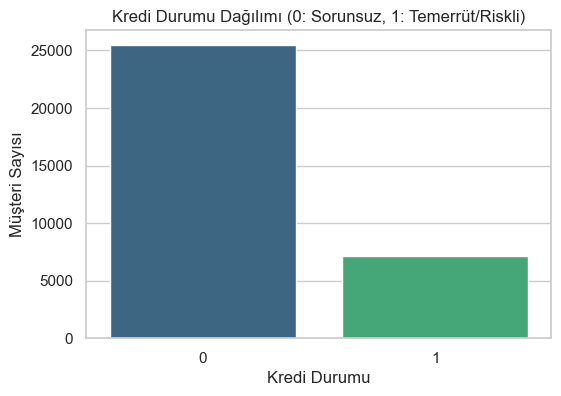

In [3]:
plt.figure(figsize=(6, 4))
sns.countplot(x='loan_status', data=df, palette='viridis')
plt.title('Kredi Durumu Dağılımı (0: Sorunsuz, 1: Temerrüt/Riskli)')
plt.xlabel('Kredi Durumu')
plt.ylabel('Müşteri Sayısı')
plt.show()

In [4]:
# --- 1. EKSİK VERİLERİ DOLDURMA ---
# Eksik değerleri o sütunun medyan değeri ile dolduruyoruz
df['person_emp_length'] = df['person_emp_length'].fillna(df['person_emp_length'].median())
df['loan_int_rate'] = df['loan_int_rate'].fillna(df['loan_int_rate'].median())

# --- 2. AYKIRI DEĞERLERİ TEMİZLEME ---
print(f"Temizlik Öncesi Satır Sayısı: {df.shape[0]}")

# Yaşı 100'den küçük eşit olanları VE çalışma süresi 60'tan küçük eşit olanları tut
df = df[(df['person_age'] <= 100) & (df['person_emp_length'] <= 60)]

# Ekstra bir mantık kontrolü: Çalışma süresi, kişinin yaşından büyük olamaz!
df = df[df['person_emp_length'] < df['person_age']]

print(f"Temizlik Sonrası Satır Sayısı: {df.shape[0]}")

# --- SON KONTROL ---
print("\nKalan Eksik Veri Sayısı:")
print(df.isnull().sum())



Temizlik Öncesi Satır Sayısı: 32581
Temizlik Sonrası Satır Sayısı: 32574

Kalan Eksik Veri Sayısı:
person_age                    0
person_income                 0
person_home_ownership         0
person_emp_length             0
loan_intent                   0
loan_grade                    0
loan_amnt                     0
loan_int_rate                 0
loan_status                   0
loan_percent_income           0
cb_person_default_on_file     0
cb_person_cred_hist_length    0
dtype: int64


In [5]:
# 1. 'Y' (Yes) ve 'N' (No) içeren sütunu doğrudan 1 ve 0'a haritalayalım
df['cb_person_default_on_file'] = df['cb_person_default_on_file'].map({'Y': 1, 'N': 0})

# 2. Birden fazla seçeneği olan metin sütunlarına One-Hot Encoding uygulayalım
# (person_home_ownership, loan_intent, loan_grade)
df = pd.get_dummies(df, columns=['person_home_ownership', 'loan_intent', 'loan_grade'], drop_first=True)

# Boole (True/False) değerleri 1 ve 0'a çevirelim (Pandas'ın yeni sürümlerinde get_dummies True/False dönebilir)
# Sadece bool tipindeki sütunları seçip integer'a çeviriyoruz
bool_cols = df.select_dtypes(include='bool').columns
df[bool_cols] = df[bool_cols].astype(int)

# 3. Yeni veri setimizin boyutuna ve yeni sütunlarımıza bakalım
print(f"Encoding Sonrası Satır ve Sütun Sayısı: {df.shape}")
display(df.head())

Encoding Sonrası Satır ve Sütun Sayısı: (32574, 23)


,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length,person_home_ownership_OTHER,...,loan_intent_HOMEIMPROVEMENT,loan_intent_MEDICAL,loan_intent_PERSONAL,loan_intent_VENTURE,loan_grade_B,loan_grade_C,loan_grade_D,loan_grade_E,loan_grade_F,loan_grade_G
1,21,9600,5.0,1000,11.14,0,0.10,0,2,0,...,0,0,0,0,1,0,0,0,0,0
2,25,9600,1.0,5500,12.87,1,0.57,0,3,0,...,0,1,0,0,0,1,0,0,0,0
3,23,65500,4.0,35000,15.23,1,0.53,0,2,0,...,0,1,0,0,0,1,0,0,0,0
4,24,54400,8.0,35000,14.27,1,0.55,1,4,0,...,0,1,0,0,0,1,0,0,0,0
5,21,9900,2.0,2500,7.14,1,0.25,0,2,0,...,0,0,0,1,0,0,0,0,0,0


In [6]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# 1. Hedef Değişken (y) ve Özelliklerin (X) Ayrılması
X = df.drop('loan_status', axis=1) # loan_status hariç her şey ipucudur
y = df['loan_status']              # Tahmin etmek istediğimiz şey

# 2. Verinin %80 Eğitim (Train), %20 Test olarak bölünmesi
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=3)

# 3. Modelin Tanımlanması ve Eğitilmesi (Ders Çalışma Aşaması)
rf_model = RandomForestClassifier(random_state=3, n_estimators=100)
rf_model.fit(X_train, y_train)

# 4. Modelin Sınava Sokulması (Tahmin Yapma)
y_pred = rf_model.predict(X_test)

# 5. Sonuçların Karne Olarak Yazdırılması
print("--- Model Başarı Karnesi ---")
print(f"Genel Doğruluk Oranı (Accuracy): %{accuracy_score(y_test, y_pred) * 100:.2f}\n")

print("Detaylı Sınıflandırma Raporu:")
print(classification_report(y_test, y_pred))

print("--- Confusion Matrix ---")
cm = confusion_matrix(y_test, y_pred)
print(cm)

--- Model Başarı Karnesi ---
Genel Doğruluk Oranı (Accuracy): %93.63

Detaylı Sınıflandırma Raporu:
              precision    recall  f1-score   support

           0       0.93      0.99      0.96      5158
           1       0.95      0.74      0.83      1357

    accuracy                           0.94      6515
   macro avg       0.94      0.86      0.89      6515
weighted avg       0.94      0.94      0.93      6515

--- Confusion Matrix ---
[[5100   58]
 [ 357 1000]]


In [7]:
# 1. Modeli 'balanced' parametresi ile yeniden eğitiyoruz
rf_model_balanced = RandomForestClassifier(random_state=3, n_estimators=100, class_weight='balanced')
rf_model_balanced.fit(X_train, y_train)

# 2. Yeni tahminleri alıyoruz
y_pred_balanced = rf_model_balanced.predict(X_test)

# 3. Yeni sonuçları yazdırıyoruz
print("--- DENGELENMİŞ (BALANCED) MODEL BAŞARI KARNESİ ---")
print(f"Genel Doğruluk Oranı (Accuracy): %{accuracy_score(y_test, y_pred_balanced) * 100:.2f}\n")
print(classification_report(y_test, y_pred_balanced))

print("--- Confusion Matrix ---")
cm_balanced = confusion_matrix(y_test, y_pred_balanced)
print(cm_balanced)

--- DENGELENMİŞ (BALANCED) MODEL BAŞARI KARNESİ ---
Genel Doğruluk Oranı (Accuracy): %93.54

              precision    recall  f1-score   support

           0       0.93      0.99      0.96      5158
           1       0.95      0.73      0.82      1357

    accuracy                           0.94      6515
   macro avg       0.94      0.86      0.89      6515
weighted avg       0.94      0.94      0.93      6515

--- Confusion Matrix ---
[[5104   54]
 [ 367  990]]


In [8]:
# 1. Tahmin olasılıklarını (probabilities) alıyoruz
# predict_proba bize iki sütun verir: [0 olma olasılığı, 1 olma olasılığı]
# Biz tüm satırları (:) ve 1. indeksteki sütunu (yani 1 olma olasılığını) alıyoruz.
y_probs = rf_model_balanced.predict_proba(X_test)[:, 1]

# 2. Yeni eşik değerimizi (threshold) belirliyoruz
threshold = 0.30

# 3. Olasılığı eşik değerine eşit veya büyük olanlara 1 (Riskli), küçüklere 0 (Öder) diyoruz
# Bu işlem True/False (Bool) döner, astype(int) ile 1 ve 0'a çeviriyoruz
y_pred_custom = (y_probs >= threshold).astype(int)

# 4. Yeni sonuçları yazdırıyoruz
print(f"--- EŞİK DEĞERİ ({threshold}) İLE MODEL BAŞARI KARNESİ ---")
print(f"Genel Doğruluk Oranı (Accuracy): %{accuracy_score(y_test, y_pred_custom) * 100:.2f}\n")
print(classification_report(y_test, y_pred_custom))

print("--- Yeni Confusion Matrix ---")
cm_custom = confusion_matrix(y_test, y_pred_custom)
print(cm_custom)

--- EŞİK DEĞERİ (0.3) İLE MODEL BAŞARI KARNESİ ---
Genel Doğruluk Oranı (Accuracy): %91.85

              precision    recall  f1-score   support

           0       0.94      0.95      0.95      5158
           1       0.82      0.78      0.80      1357

    accuracy                           0.92      6515
   macro avg       0.88      0.87      0.87      6515
weighted avg       0.92      0.92      0.92      6515

--- Yeni Confusion Matrix ---
[[4922  236]
 [ 295 1062]]


In [9]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

# 1. Sadece kredisi onaylanan (Sorunsuz / 0) müşterileri filtreliyoruz
df_approved = df[df['loan_status'] == 0].copy()

# 2. Yeni X ve y'mizi belirliyoruz
# Artık hedefimiz 'loan_amnt' (Kredi Miktarı)
X_reg = df_approved.drop(['loan_status', 'loan_amnt'], axis=1)
y_reg = df_approved['loan_amnt']

# 3. Veriyi %80 Eğitim ve %20 Test olarak bölüyoruz
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(X_reg, y_reg, test_size=0.2, random_state=42)

# 4. Regresyon Modelini Kuruyoruz (Bu kez Classifier değil, Regressor kullanıyoruz!)
rf_reg_model = RandomForestRegressor(random_state=3, n_estimators=100)
rf_reg_model.fit(X_train_reg, y_train_reg)

# 5. Modelin Sınava Sokulması (Tahmin Yapma)
y_pred_reg = rf_reg_model.predict(X_test_reg)

# 6. Sonuçları Yazdırıyoruz
print("--- REGRESYON MODELİ BAŞARI KARNESİ ---")
print(f"Ortalama Mutlak Hata (MAE): {mean_absolute_error(y_test_reg, y_pred_reg):.0f} Dolar")
print(f"R-Kare (R2 Score): {r2_score(y_test_reg, y_pred_reg):.2f}")

--- REGRESYON MODELİ BAŞARI KARNESİ ---
Ortalama Mutlak Hata (MAE): 137 Dolar
R-Kare (R2 Score): 1.00


In [10]:
# 1. Veri Sızıntısını (Data Leakage) önlemek için kopya sütununu çıkarıyoruz
# loan_percent_income: Modelin kopya çektiği matematiksel oran
X_reg_real = df_approved.drop(['loan_status', 'loan_amnt', 'loan_percent_income'], axis=1)
y_reg_real = df_approved['loan_amnt']

# 2. Veriyi tekrar %80 Eğitim ve %20 Test olarak bölüyoruz
X_train_reg_real, X_test_reg_real, y_train_reg_real, y_test_reg_real = train_test_split(
    X_reg_real, y_reg_real, test_size=0.2, random_state=42
)

# 3. Regresyon Modelini Yeniden Kuruyoruz
rf_reg_model_real = RandomForestRegressor(random_state=42, n_estimators=100)
rf_reg_model_real.fit(X_train_reg_real, y_train_reg_real)

# 4. Tahminleri alıyoruz (Sınav vakti!)
y_pred_reg_real = rf_reg_model_real.predict(X_test_reg_real)

# 5. GERÇEK Sonuçları Yazdırıyoruz
print("--- SIZINTI GİDERİLMİŞ GERÇEK REGRESYON MODELİ BAŞARI KARNESİ ---")
print(f"Ortalama Mutlak Hata (MAE): {mean_absolute_error(y_test_reg_real, y_pred_reg_real):.0f} Dolar")
print(f"R-Kare (R2 Score): {r2_score(y_test_reg_real, y_pred_reg_real):.2f}")

--- SIZINTI GİDERİLMİŞ GERÇEK REGRESYON MODELİ BAŞARI KARNESİ ---
Ortalama Mutlak Hata (MAE): 3885 Dolar
R-Kare (R2 Score): 0.26
